# 01 Design selector synthetic demo

This notebook is the core method demonstration. We simulate an online platform where the true launch effect and oracle design risk are known. The outputs are aligned with the paper's interference-aware design selector: a finite-design guarantee diagnostic, a design-risk ranking, a Pareto frontier, an uncertainty shortlist, an interference-strength sensitivity curve, and a continuous regime-transition plot showing when the selected design changes.


In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "online_experiment_designs_under_interference" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "code" / "src"))

from config import ProjectPaths
from designs import design_catalog_frame, pareto_frontier, uncertainty_shortlist
from experiment_suite import (
    run_continuous_regime_transition,
    run_interference_sensitivity,
    run_regime_reversal_diagnostic,
    run_recommended_synthetic_scenarios,
    run_selector_guarantee_demo,
)
from figures import (
    plot_design_risk,
    plot_regime_reversal_map,
    plot_regime_transition_curves,
    plot_sensitivity_grid,
    plot_selector_guarantee,
)
from progress import ProgressLogger
from tables import write_table

paths = ProjectPaths.from_anywhere(PROJECT_ROOT)
paths.ensure()
progress = ProgressLogger("01-synthetic")


In [2]:
design_catalog = design_catalog_frame()
write_table(design_catalog, paths.table_dir / "01_design_catalog.csv")
design_catalog

[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/01_design_catalog.csv


,name,assignment_unit,estimand,interference_coverage,operational_cost,estimand_mismatch,notes
0,user_randomization,user,direct user-level intent-to-treat effect,low,0.10,0.65,"High power but vulnerable to shared inventory,..."
1,cluster_randomization,cluster,cluster-level total effect under local interfe...,medium,0.35,0.30,Useful when a graph or market partition captur...
2,switchback,time block,time-local marketplace or product-surface effect,medium-high,0.45,0.25,Useful when all users share fast-moving state;...
3,budget_split,budget universe,budget-isolated marketplace effect,high for budget/pacing,0.70,0.20,Credible for ads budget interference but opera...
4,two_stage_saturation,cluster and saturation cell,direct and spillover decomposition,high for measurable spillovers,0.80,0.15,Best for learning spillover response curves; u...
5,mixed_randomization,multiple axes,multi-population effect with selected spillove...,high,0.90,0.10,Flexible but complex; useful when multiple uni...


In [3]:
progress.log("Running controlled synthetic scenarios with known true launch effects.")
scenario_results = run_recommended_synthetic_scenarios(n_reps=120)
write_table(scenario_results, paths.table_dir / "01_synthetic_scenario_design_scores.csv")
scenario_results.groupby("case").head(3)

[04:09:11] 01-synthetic: Running controlled synthetic scenarios with known true launch effects.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/01_synthetic_scenario_design_scores.csv


,design,mean_estimate,sd,mean_mde,assignment_units,exposure_distance,assignment_unit_variance,planning_mde,spillover_contamination,carryover_contamination,...,mde,operational_cost,exposure_distance_norm,assignment_unit_variance_norm,planning_mde_norm,contamination_risk_norm,operational_cost_norm,estimand_mismatch_norm,design_risk,case
0,cluster_randomization,0.089847,0.008774,0.029811,55.0,0.509733,0.003131,0.029811,0.121585,0.031128,...,0.029811,0.35,0.987575,0.044660,0.432045,0.314812,0.388889,0.987575,2.305926,low_interference
1,budget_split,0.086895,0.010556,0.038934,27.0,0.506120,0.002633,0.038934,0.117436,0.031357,...,0.038934,0.70,0.980575,0.037557,0.564250,0.305552,0.777778,0.980575,2.558681,low_interference
2,two_stage_saturation,0.033164,0.008697,0.010355,880.0,0.507536,0.006021,0.010355,0.224688,0.421930,...,0.010355,0.80,0.983319,0.085883,0.150078,1.000000,0.888889,0.983319,2.653742,low_interference
6,cluster_randomization,0.140494,0.009400,0.043466,55.0,0.511631,0.006645,0.043466,0.121251,0.031008,...,0.043466,0.35,0.991839,0.094096,0.479998,0.314066,0.388889,0.991839,2.388139,budget_spillover
7,budget_split,0.119564,0.010090,0.050478,27.0,0.515840,0.004408,0.050478,0.117245,0.030740,...,0.050478,0.70,1.000000,0.062418,0.557429,0.304559,0.777778,1.000000,2.605057,budget_spillover
8,two_stage_saturation,0.051219,0.009449,0.011240,880.0,0.506554,0.007095,0.011240,0.224648,0.421573,...,0.011240,0.80,0.981998,0.100466,0.124117,1.000000,0.888889,0.981998,2.643758,budget_spillover
12,cluster_randomization,0.161114,0.012666,0.048510,55.0,0.512134,0.008287,0.048510,0.121615,0.030976,...,0.048510,0.35,0.987246,0.115756,0.597101,0.314692,0.388889,0.987246,2.485998,temporal_carryover
13,two_stage_saturation,0.055468,0.010317,0.011557,880.0,0.510363,0.007501,0.011557,0.224713,0.421917,...,0.011557,0.80,0.983832,0.104786,0.142251,1.000000,0.888889,0.983832,2.663840,temporal_carryover
14,mixed_randomization,0.099708,0.005368,0.013304,880.0,0.508224,0.009940,0.013304,0.121190,0.501902,...,0.013304,0.90,0.979709,0.138844,0.163763,0.854178,1.000000,0.979709,2.684797,temporal_carryover
18,cluster_randomization,0.155282,0.011446,0.046044,55.0,0.507652,0.007465,0.046044,0.121506,0.031260,...,0.046044,0.35,0.997823,0.116141,0.446787,0.315025,0.388889,0.997823,2.391173,network_spillover


[04:10:48] 01-synthetic: Checking the finite-design selector guarantee with a noisy planning study and an oracle simulation.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/01_selector_planning_risk.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/01_selector_oracle_risk.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/01_selector_theorem_diagnostic.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/01_selector_theorem_diagnostic.png


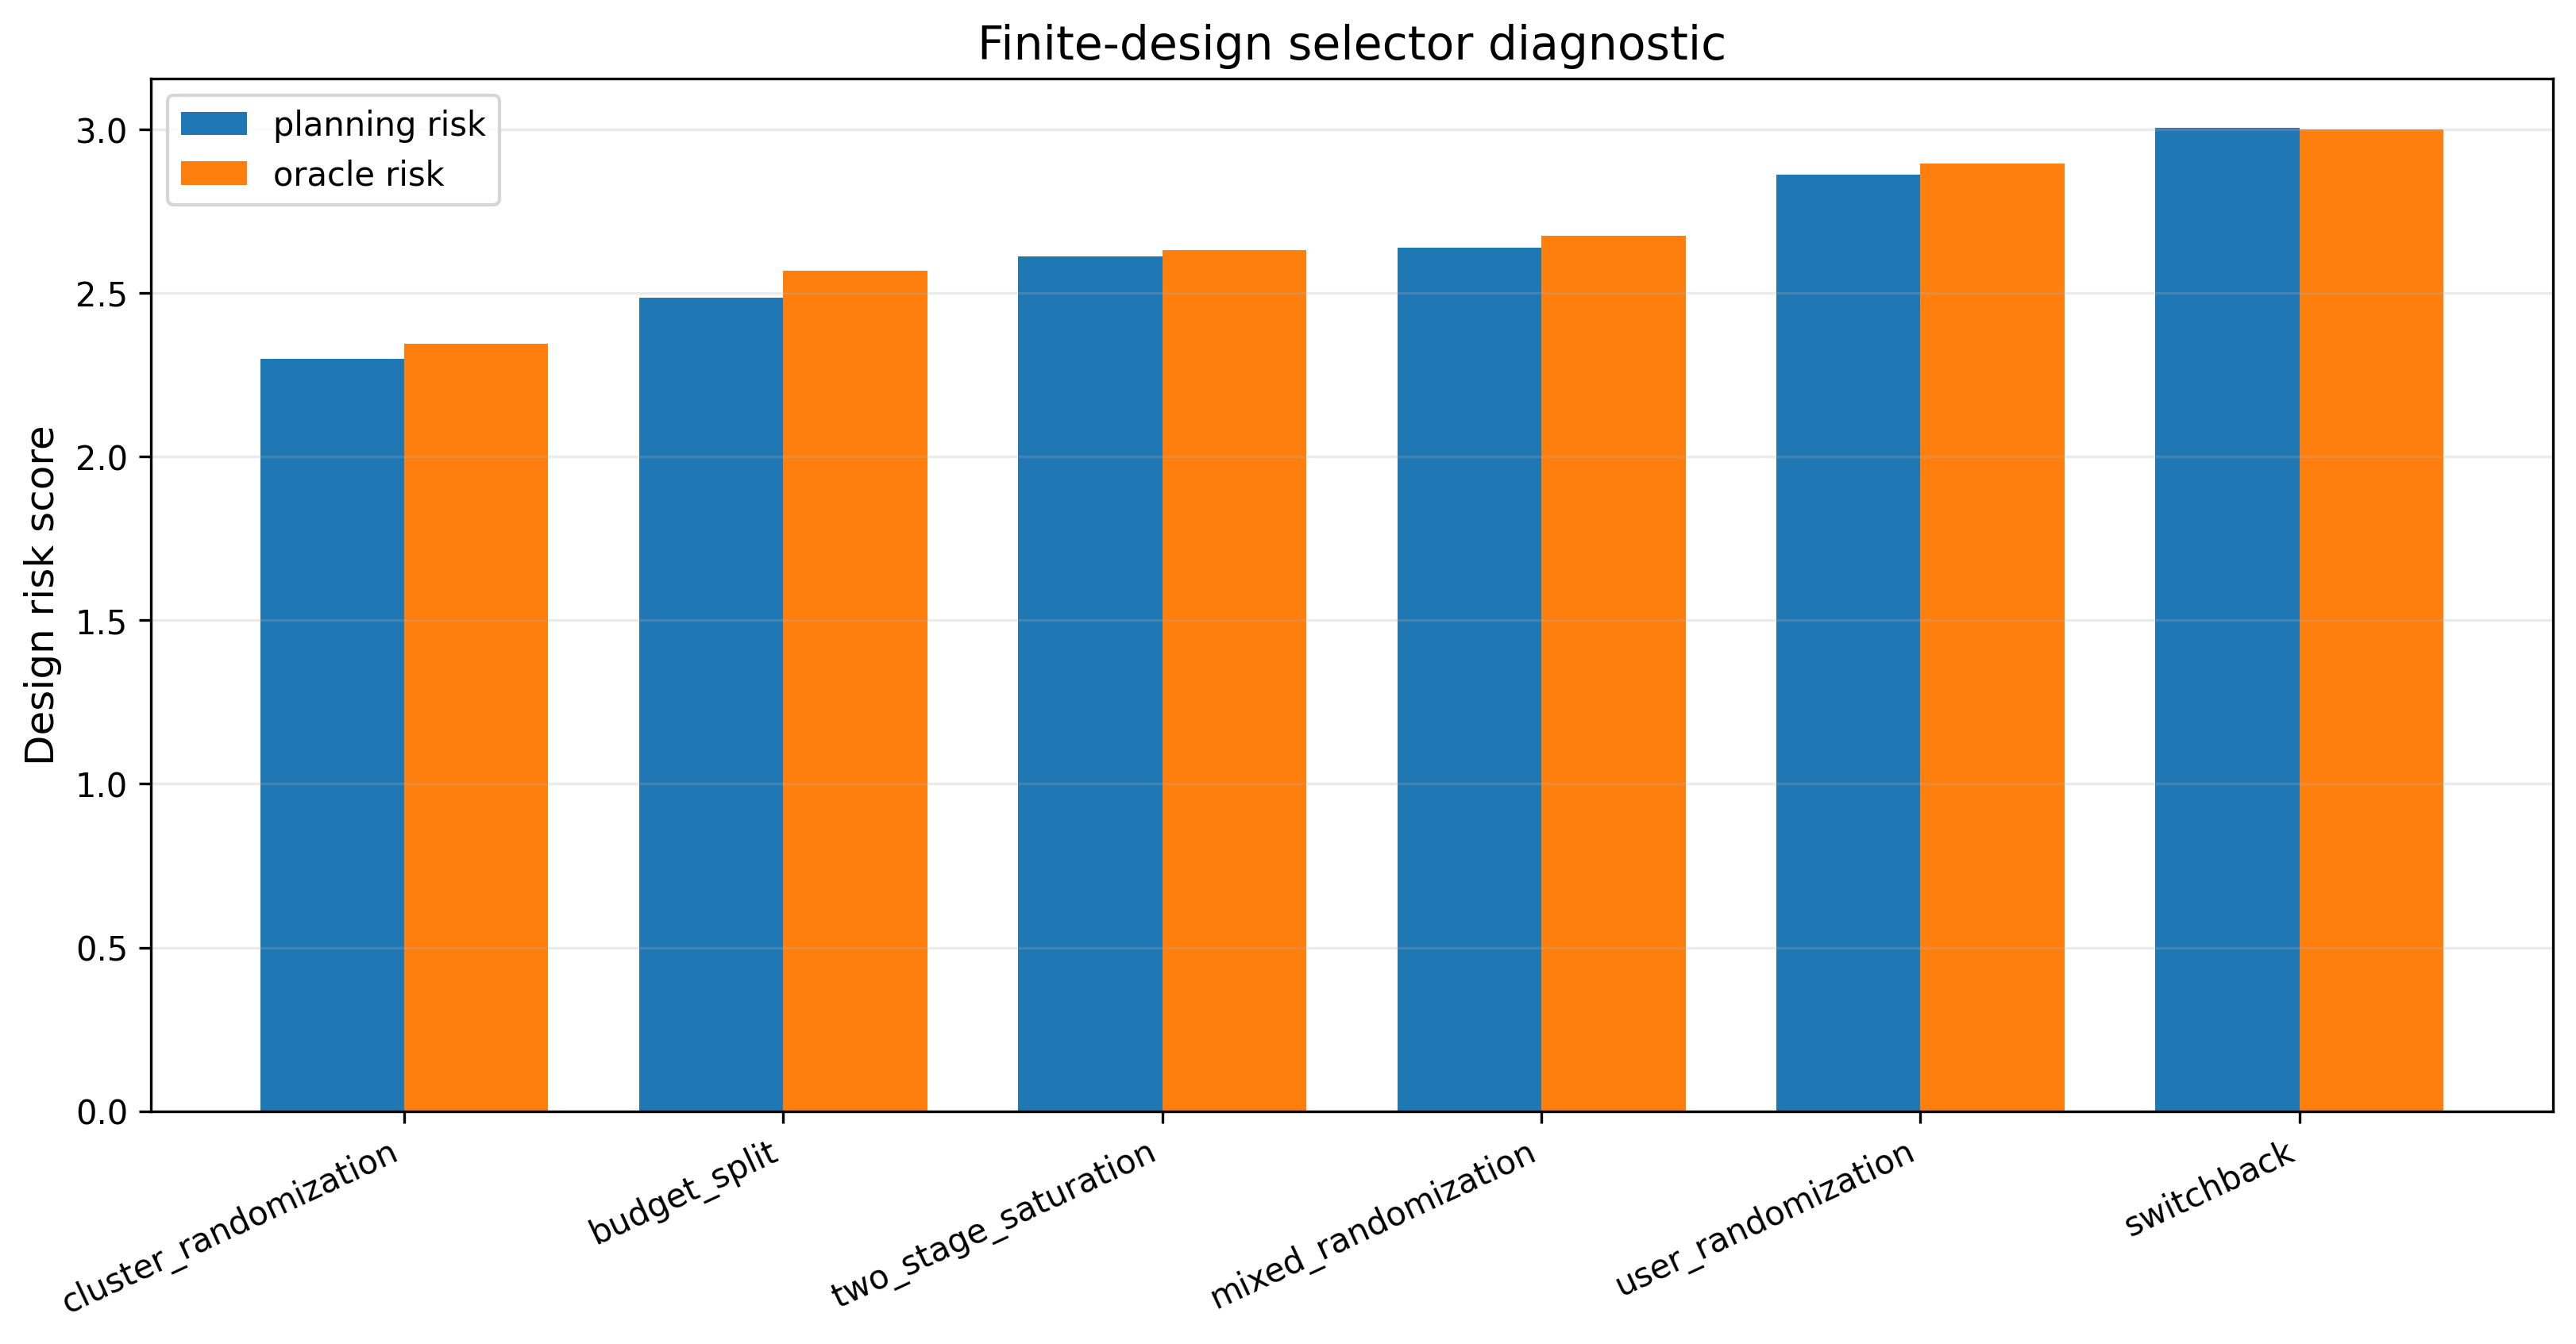

,selected_design,oracle_best_design,epsilon,two_epsilon_bound,oracle_excess_risk,bound_holds
0,cluster_randomization,cluster_randomization,0.083028,0.166057,0.0,True


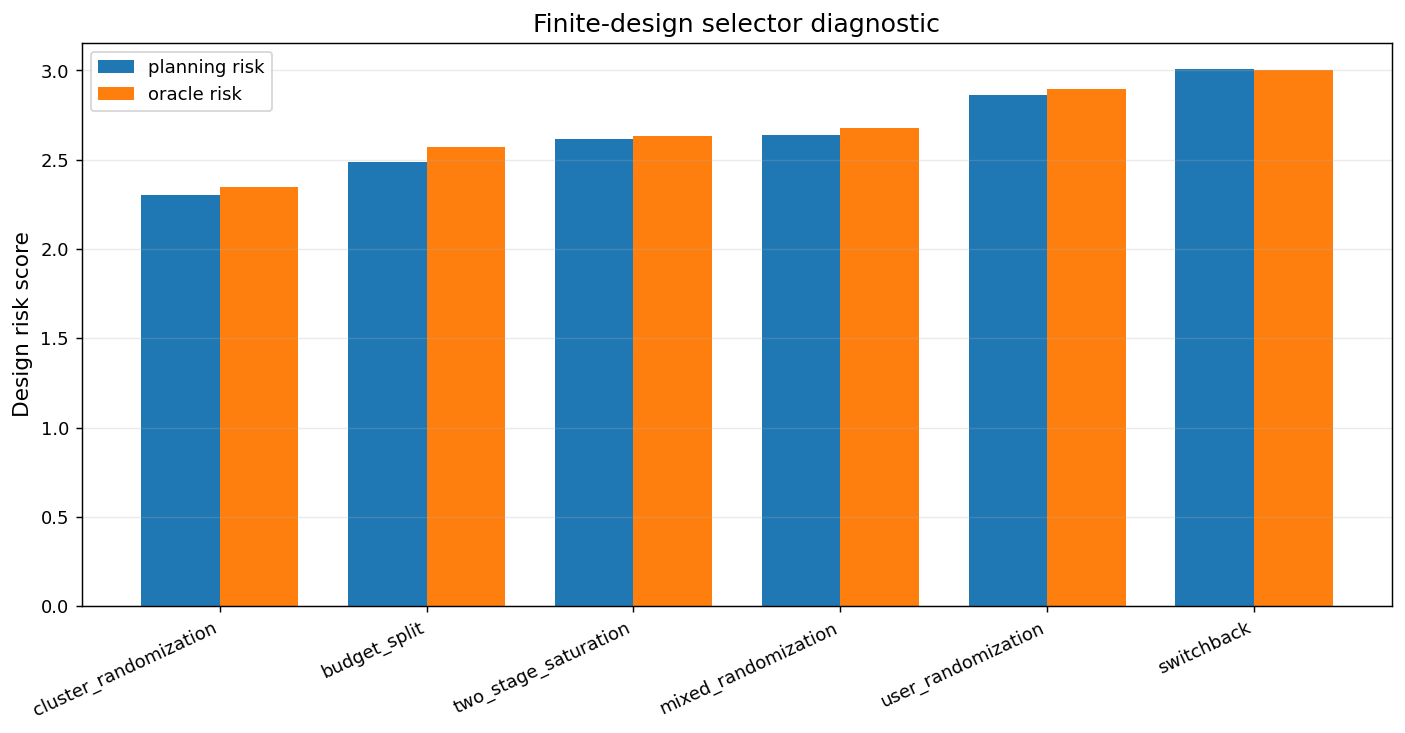

In [4]:
progress.log("Checking the finite-design selector guarantee with a noisy planning study and an oracle simulation.")
plan_ranked, oracle_ranked, theorem_diagnostic = run_selector_guarantee_demo(
    n_oracle_reps=260,
    n_plan_reps=45,
)
write_table(plan_ranked, paths.table_dir / "01_selector_planning_risk.csv")
write_table(oracle_ranked, paths.table_dir / "01_selector_oracle_risk.csv")
write_table(theorem_diagnostic, paths.table_dir / "01_selector_theorem_diagnostic.csv")
fig_path = paths.figure_dir / "01_selector_theorem_diagnostic.png"
plot_selector_guarantee(plan_ranked, oracle_ranked, fig_path)
display(Image(filename=fig_path))
theorem_diagnostic

In [5]:
progress.log("Writing the budget-spillover Pareto frontier and uncertainty shortlist.")
case = scenario_results[scenario_results["case"] == "budget_spillover"].copy()
frontier = pareto_frontier(case)
shortlist = uncertainty_shortlist(case)
write_table(frontier, paths.table_dir / "01_budget_spillover_pareto_frontier.csv")
write_table(shortlist, paths.table_dir / "01_budget_spillover_uncertainty_shortlist.csv")
shortlist[["design", "design_risk", "shortlist_threshold", "exposure_distance", "assignment_unit_variance", "planning_mde", "contamination_risk", "estimand_mismatch"]]

[04:11:49] 01-synthetic: Writing the budget-spillover Pareto frontier and uncertainty shortlist.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/01_budget_spillover_pareto_frontier.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/01_budget_spillover_uncertainty_shortlist.csv


,design,design_risk,shortlist_threshold,exposure_distance,assignment_unit_variance,planning_mde,contamination_risk,estimand_mismatch
0,cluster_randomization,2.388139,2.865767,0.511631,0.006645,0.043466,0.091170,0.511631
1,budget_split,2.605057,2.865767,0.515840,0.004408,0.050478,0.088410,0.515840
2,two_stage_saturation,2.643758,2.865767,0.506554,0.007095,0.011240,0.290290,0.506554
3,mixed_randomization,2.679639,2.865767,0.506169,0.010292,0.013539,0.246336,0.506169


[04:11:49] 01-synthetic: Plotting the design-risk ranking for the budget-spillover case.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/01_budget_spillover_design_risk.png


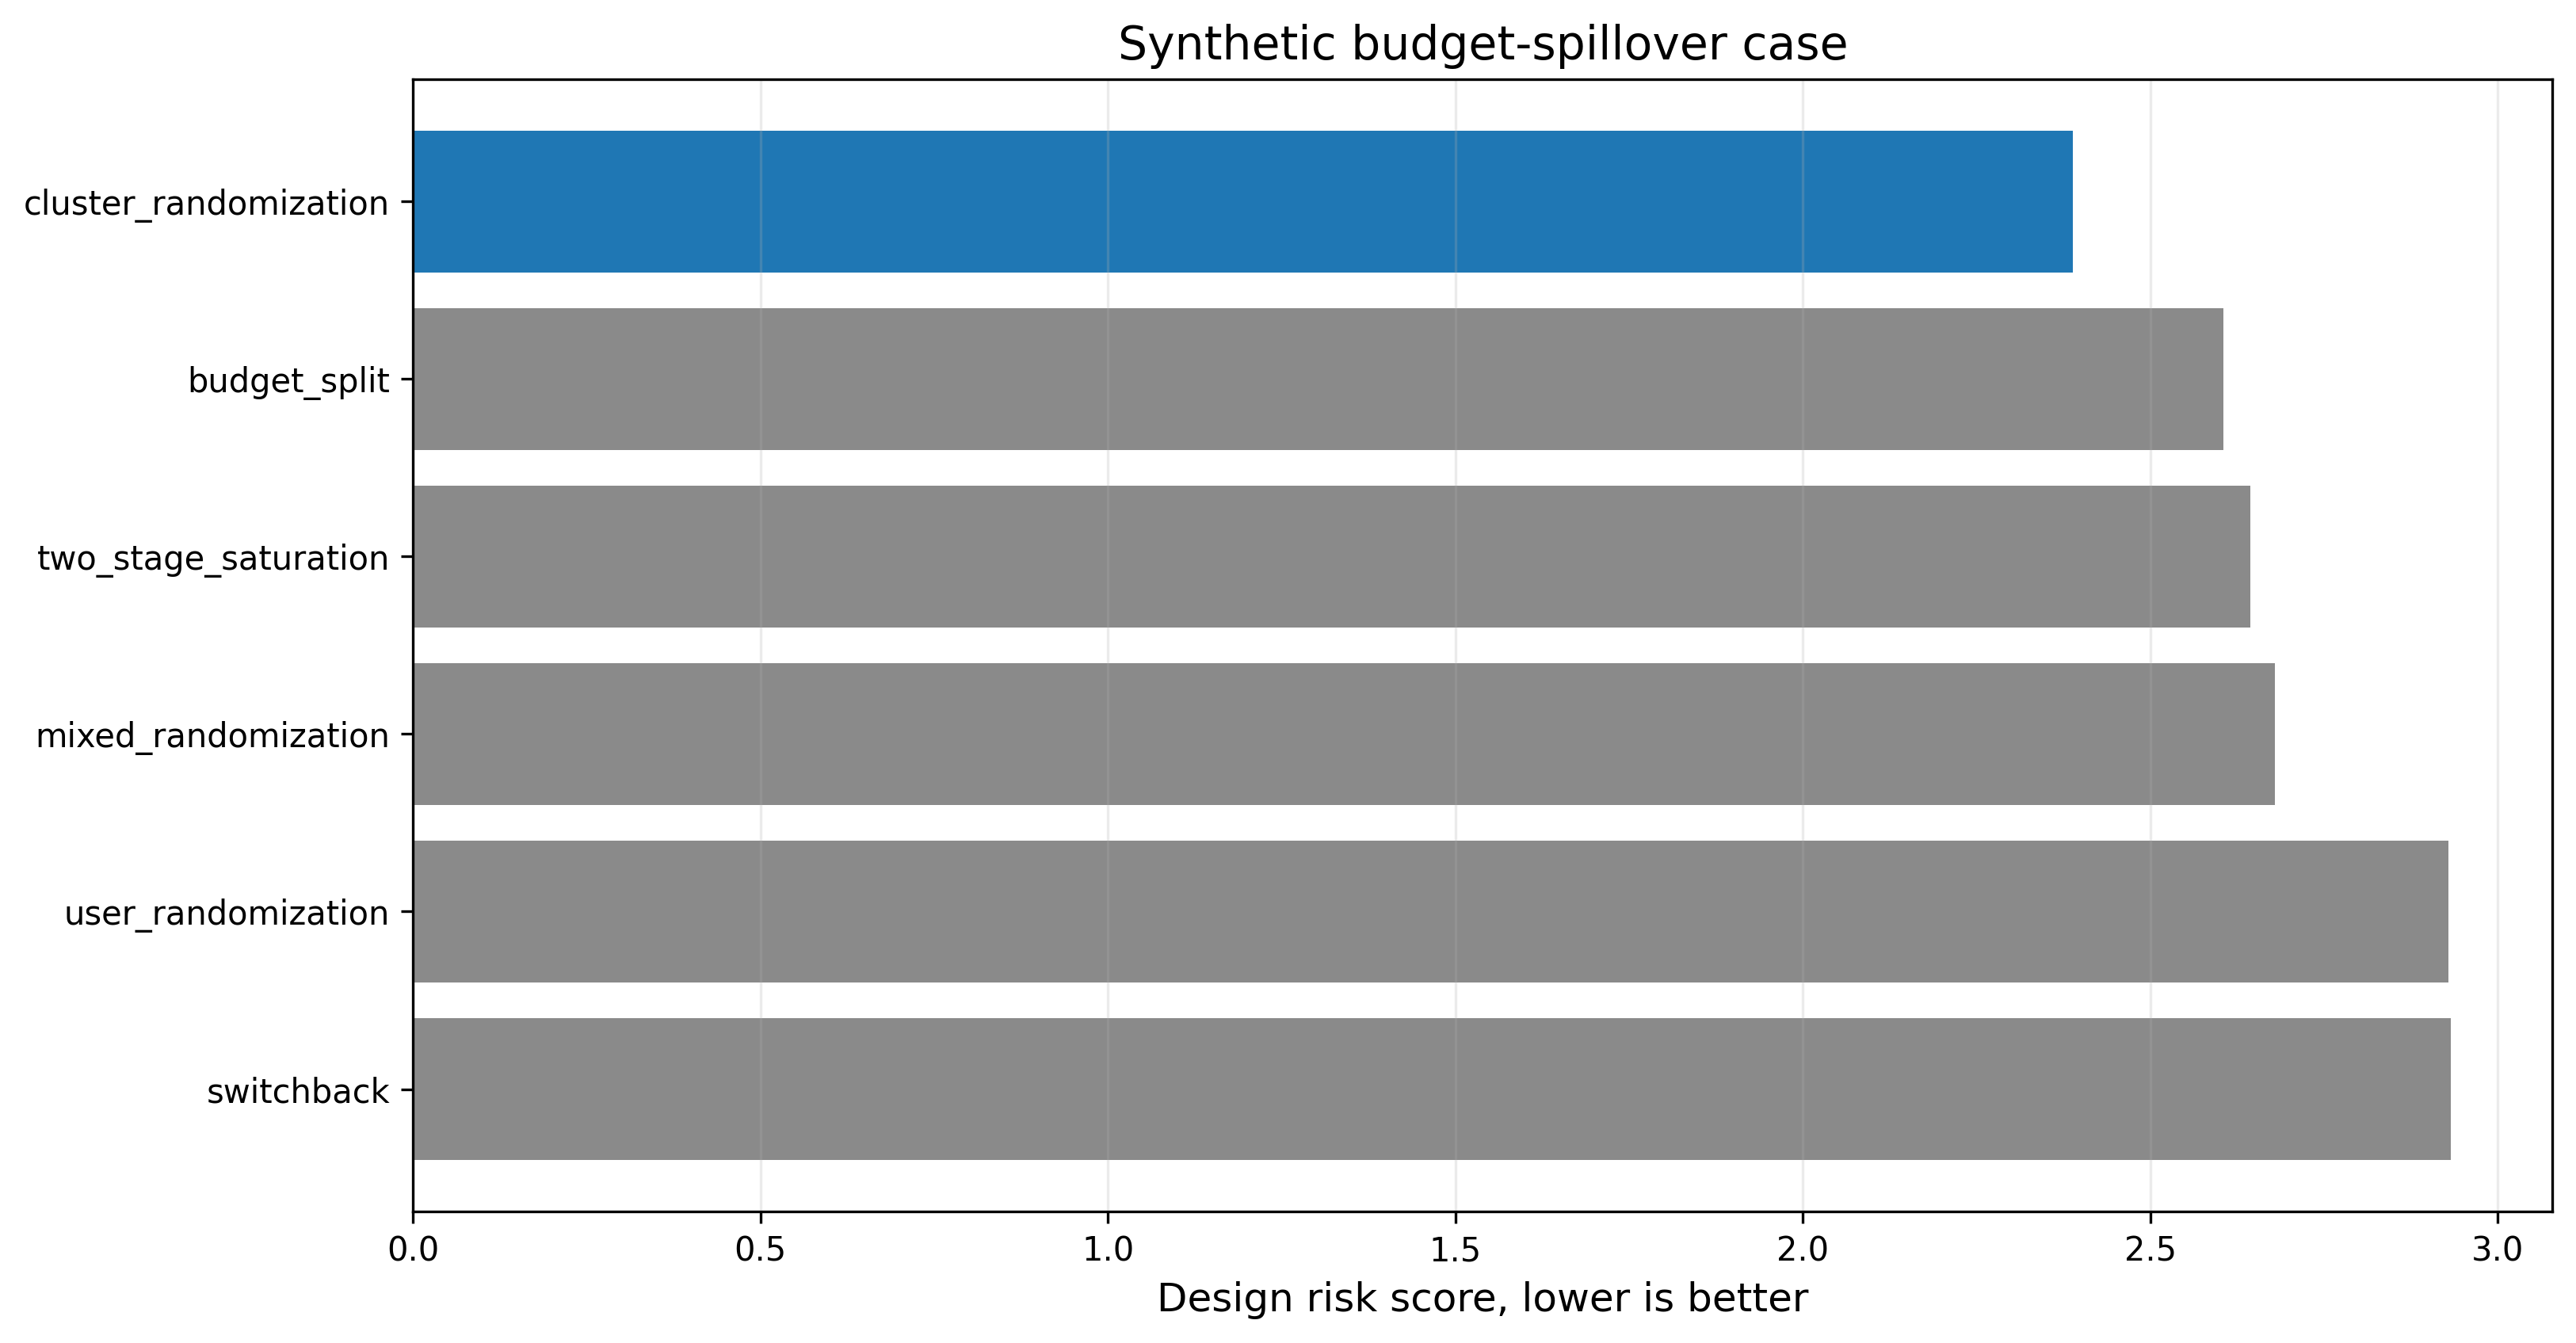

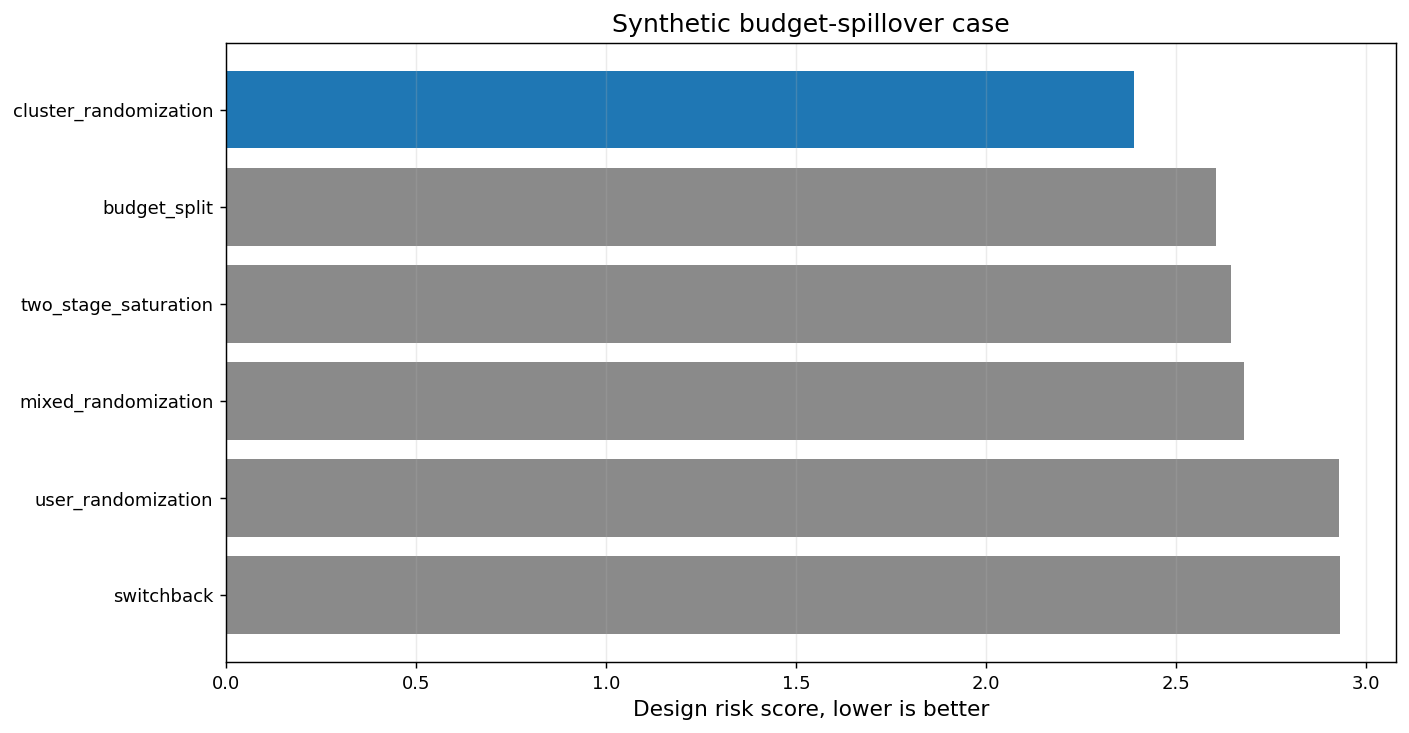

In [6]:
progress.log("Plotting the design-risk ranking for the budget-spillover case.")
fig_path = paths.figure_dir / "01_budget_spillover_design_risk.png"
plot_design_risk(case, "Synthetic budget-spillover case", fig_path)
display(Image(filename=fig_path))

[04:11:49] 01-synthetic: Sweeping interference strength to show when naive user randomization degrades.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/01_interference_sensitivity.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/01_interference_sensitivity.png


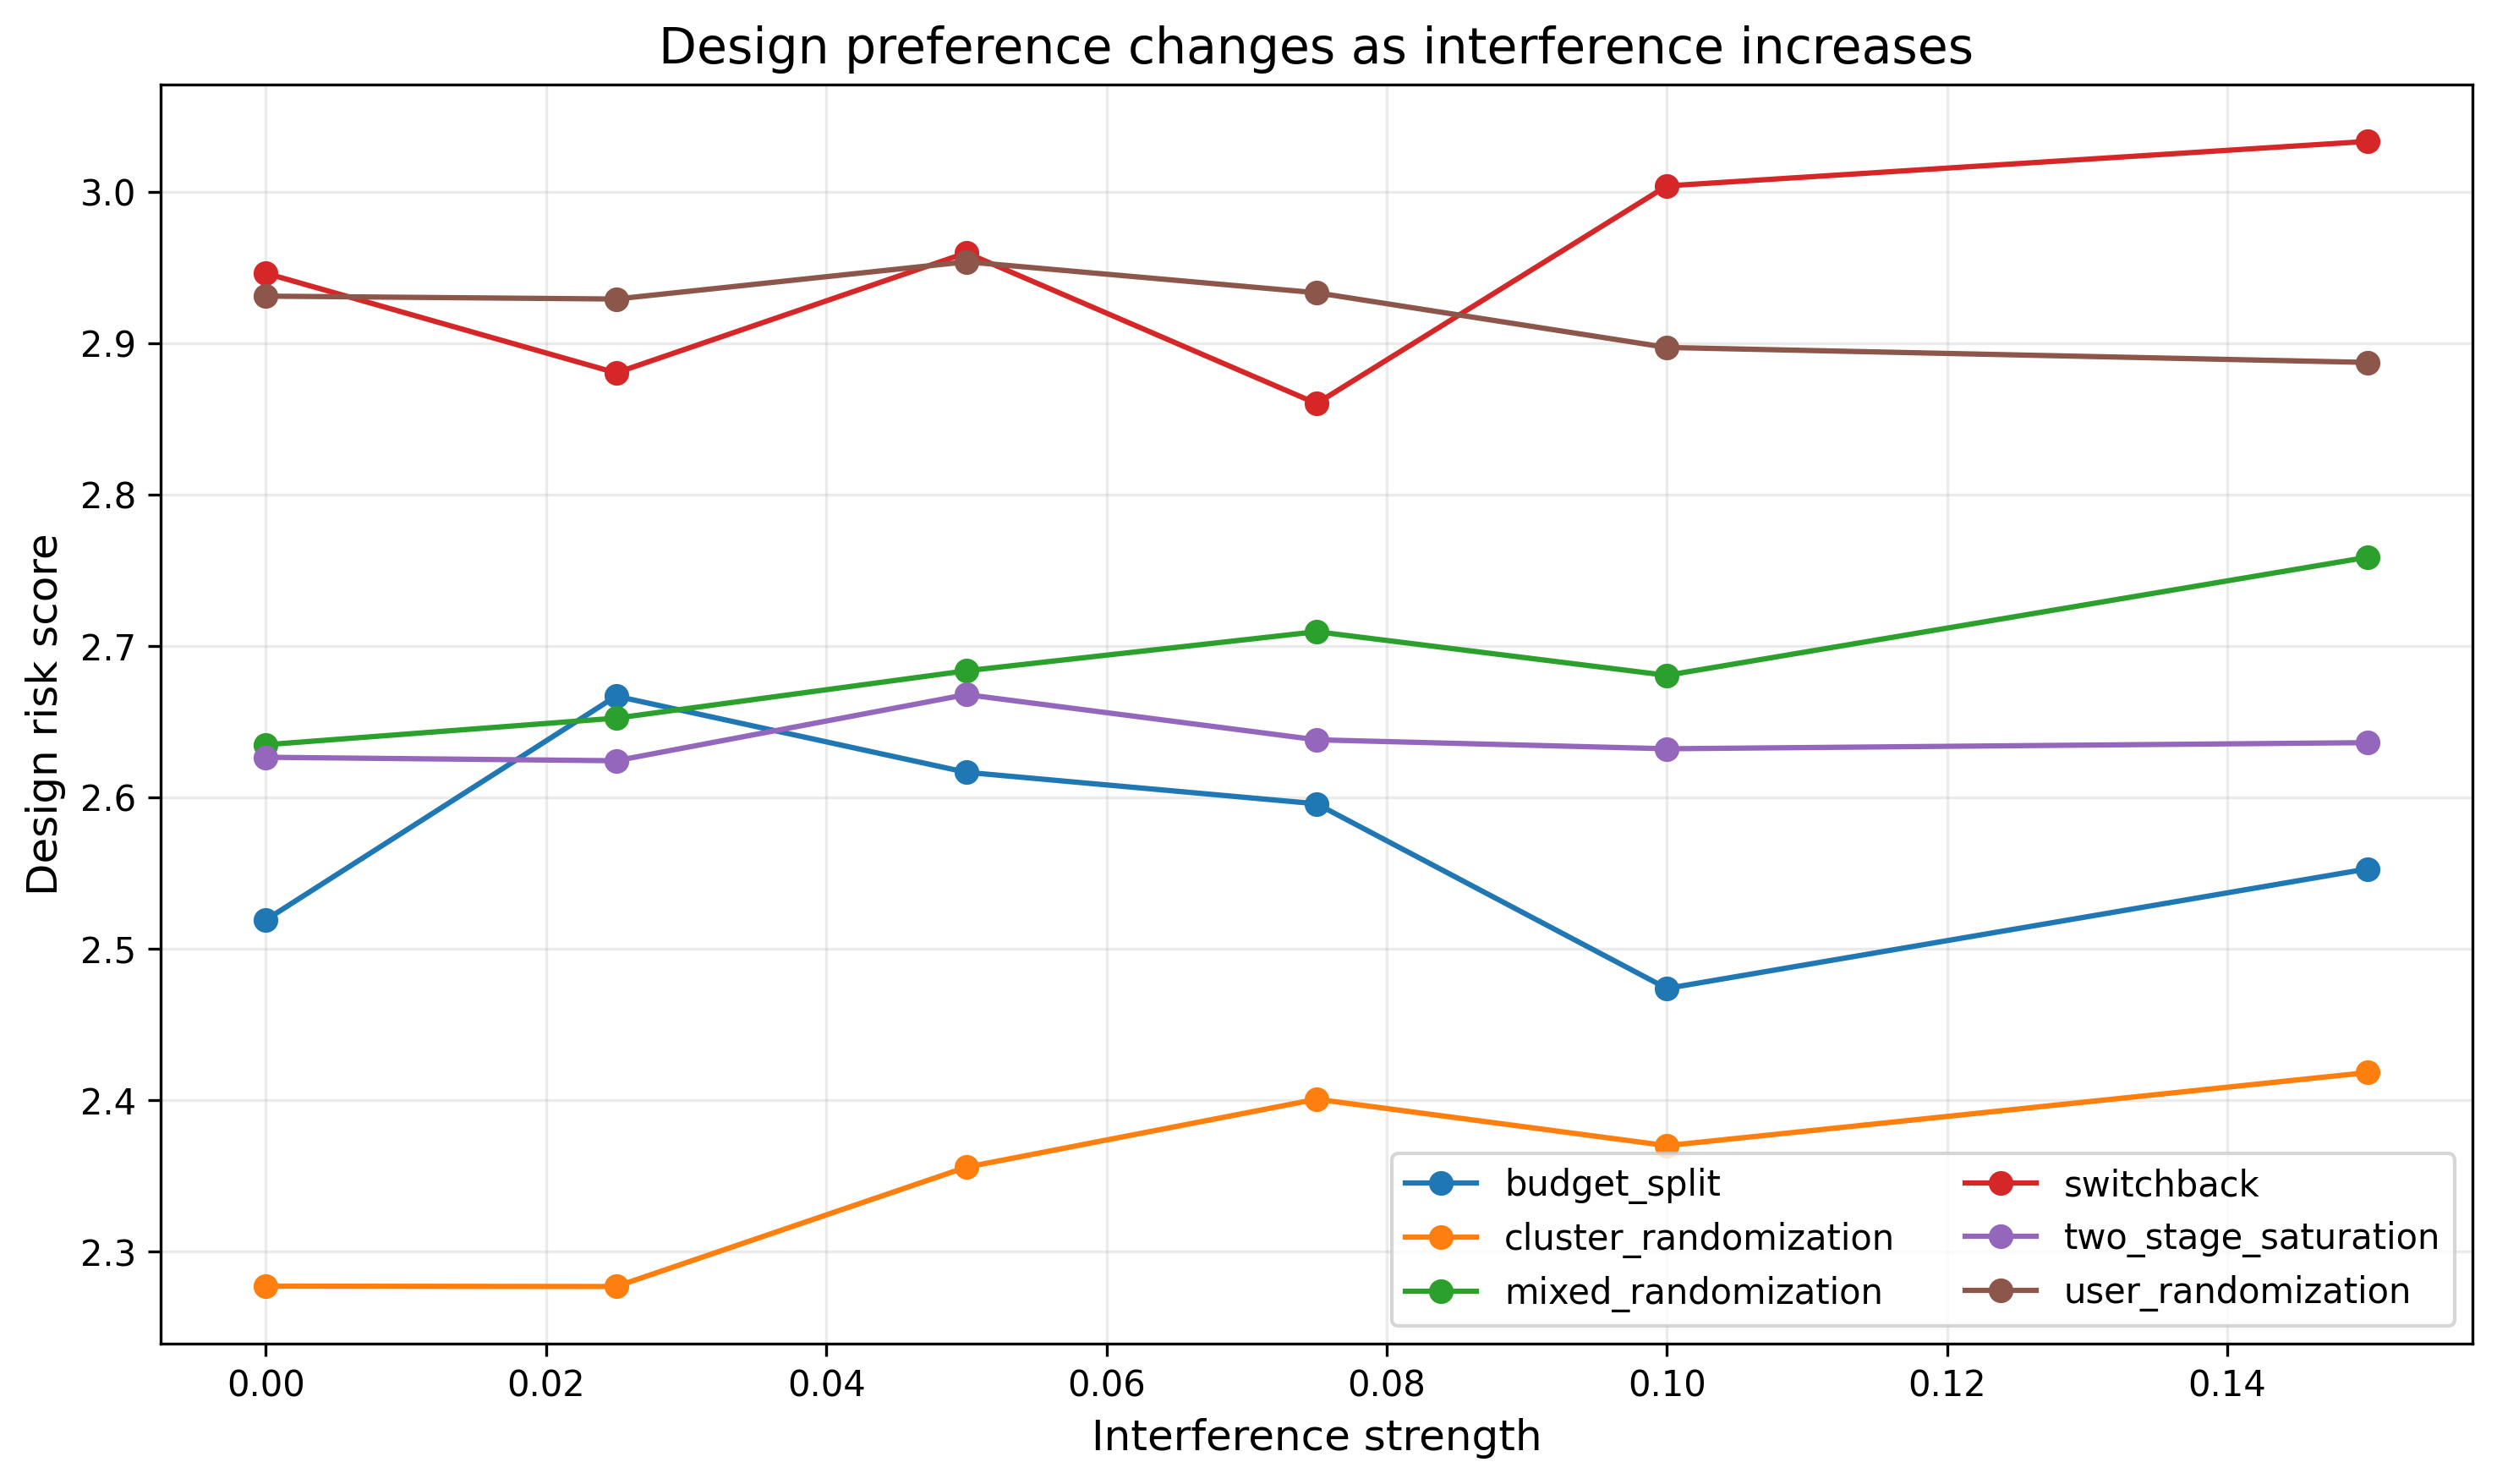

[04:12:56] 01-synthetic: Constructing a mechanism-regime reversal diagnostic for the design-regime theorem.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/01_regime_reversal_design_map.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/01_regime_reversal_design_map.png


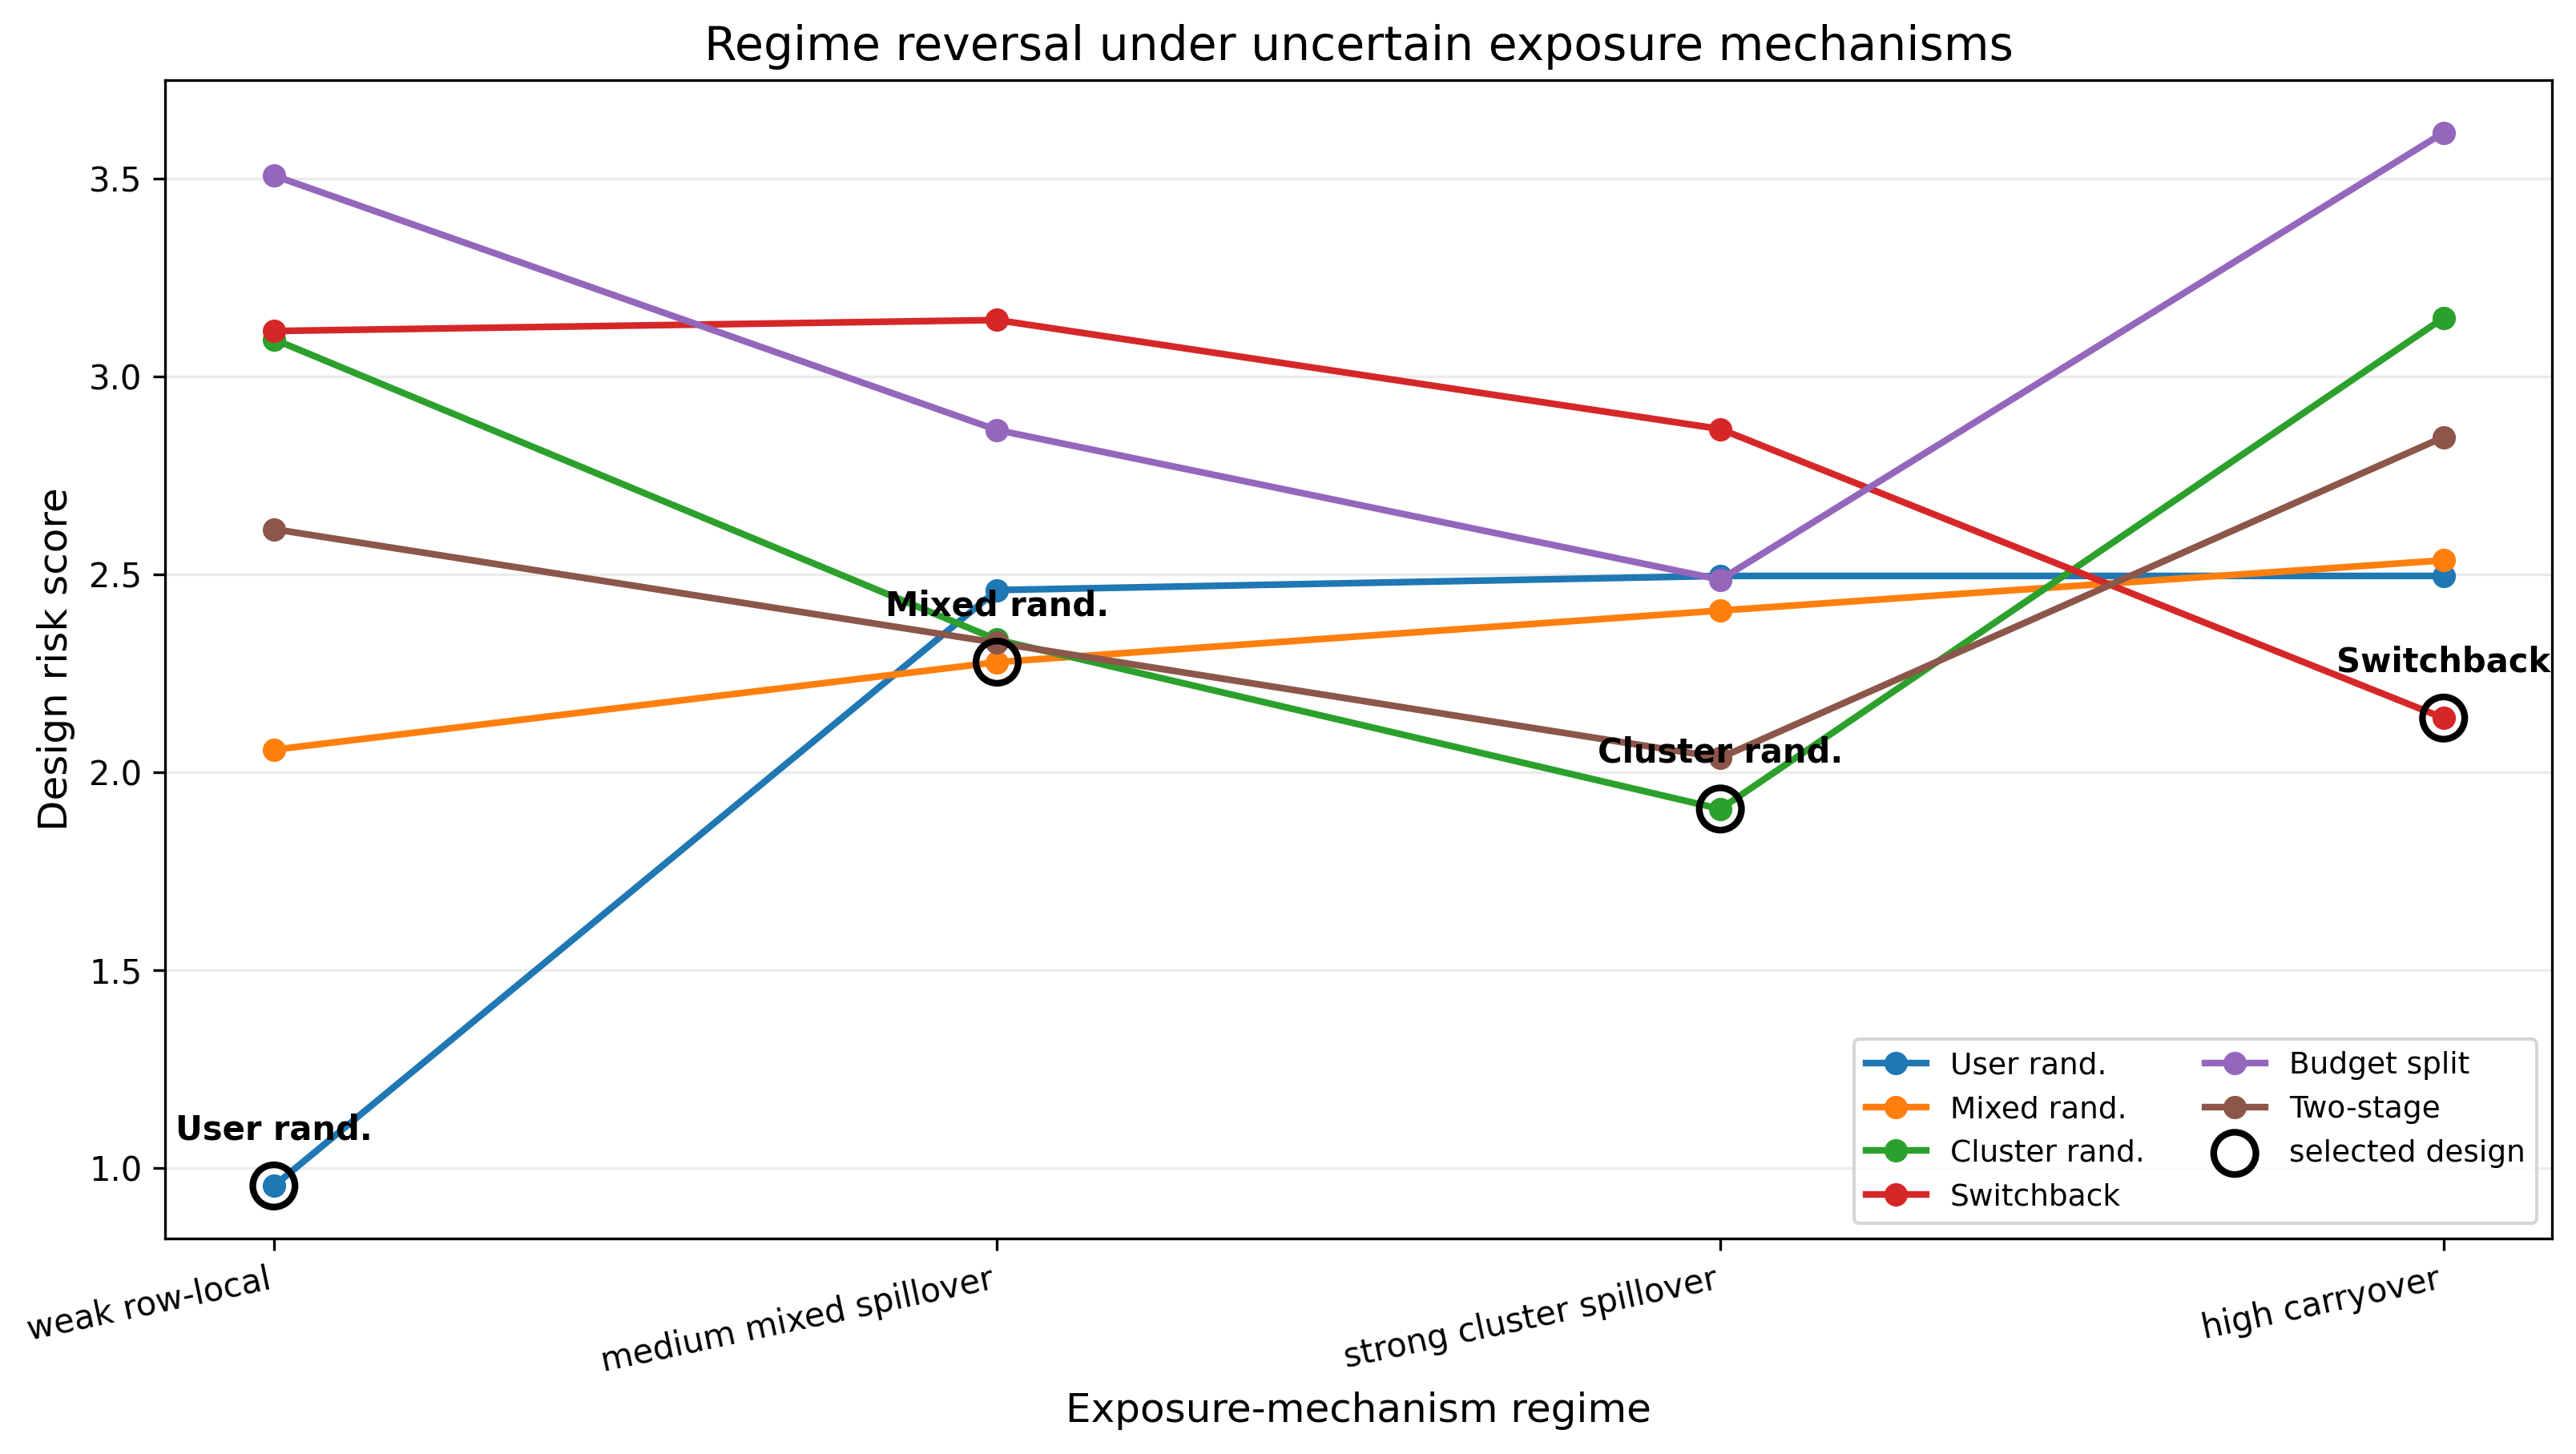

[04:12:56] 01-synthetic: Sweeping the continuous regime-transition curve for the centerpiece figure.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/01_regime_transition_design_risks.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/01_regime_transition_design_risks.png


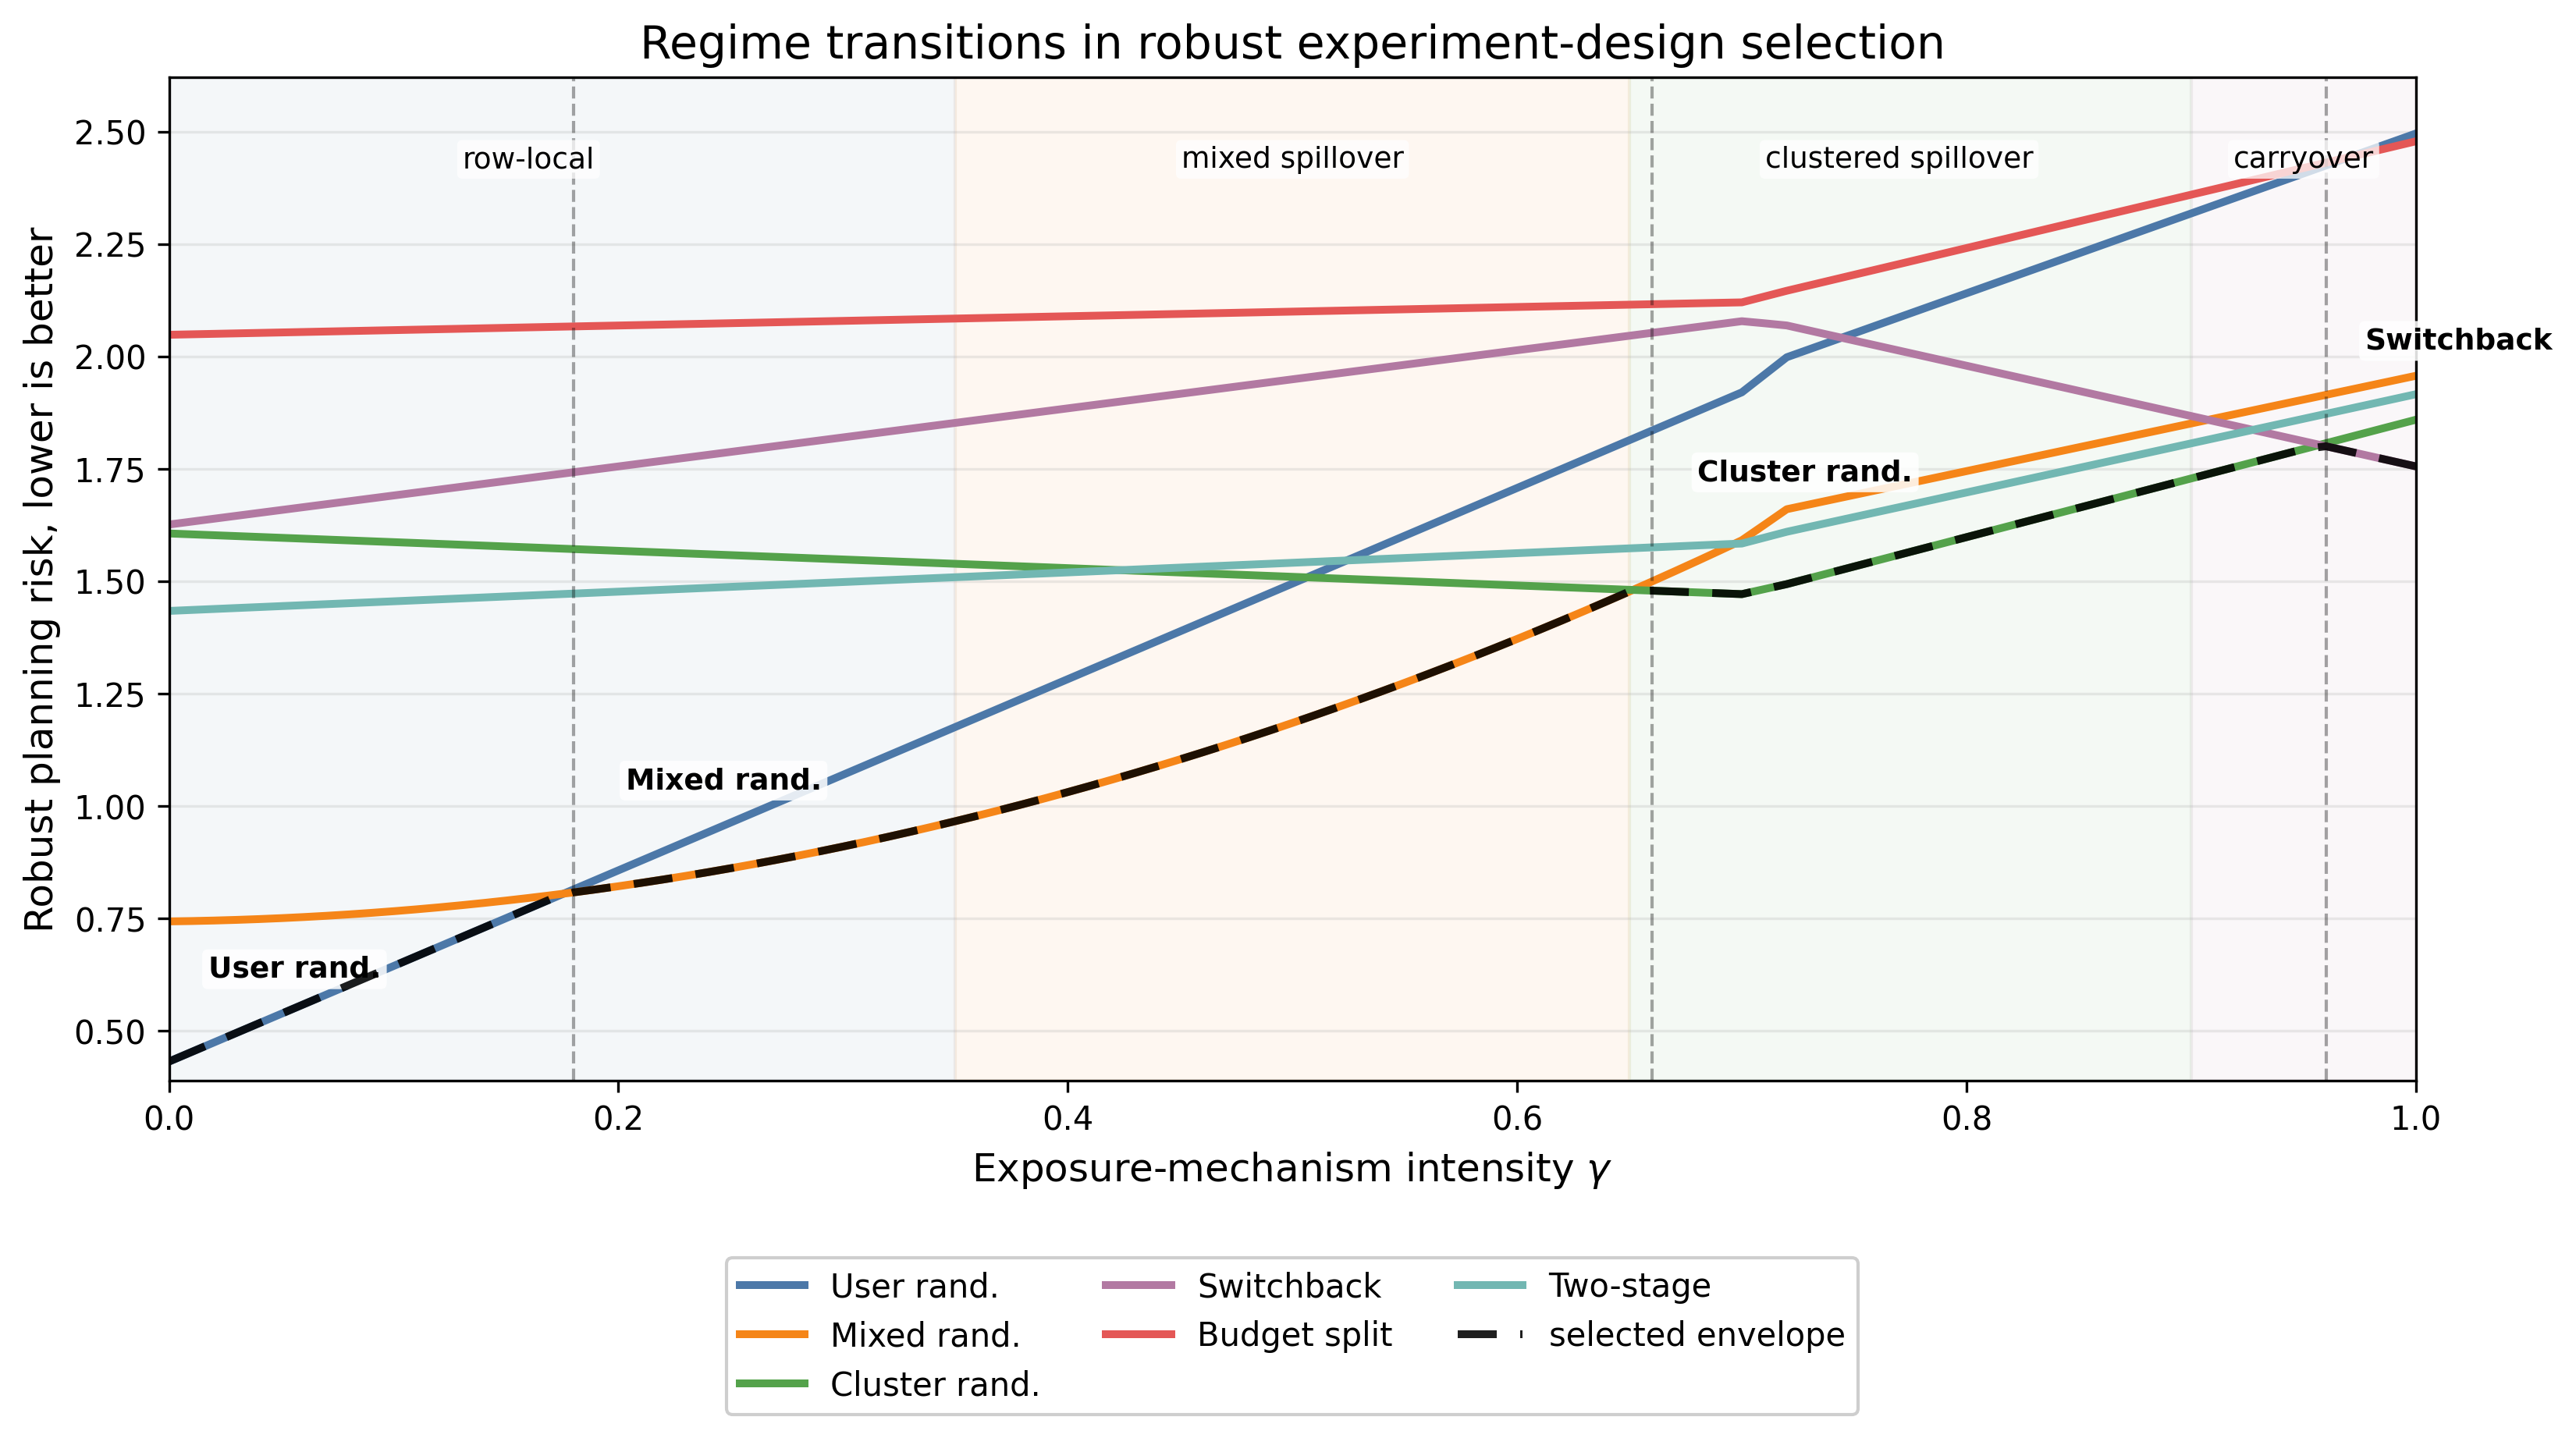

,min_gamma,max_gamma,n_grid_points
design,,,
cluster_randomization,0.66,0.95,30
mixed_randomization,0.18,0.65,48
switchback,0.96,1.00,5
user_randomization,0.00,0.17,18


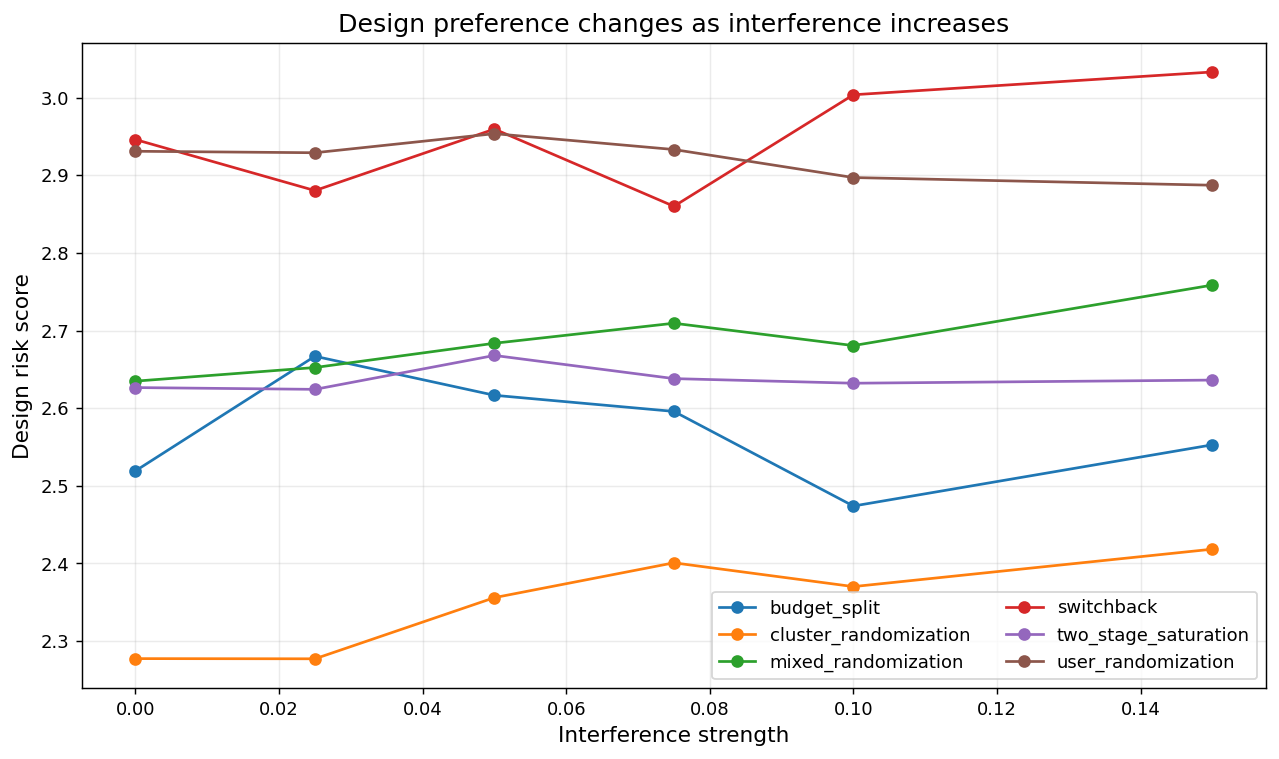

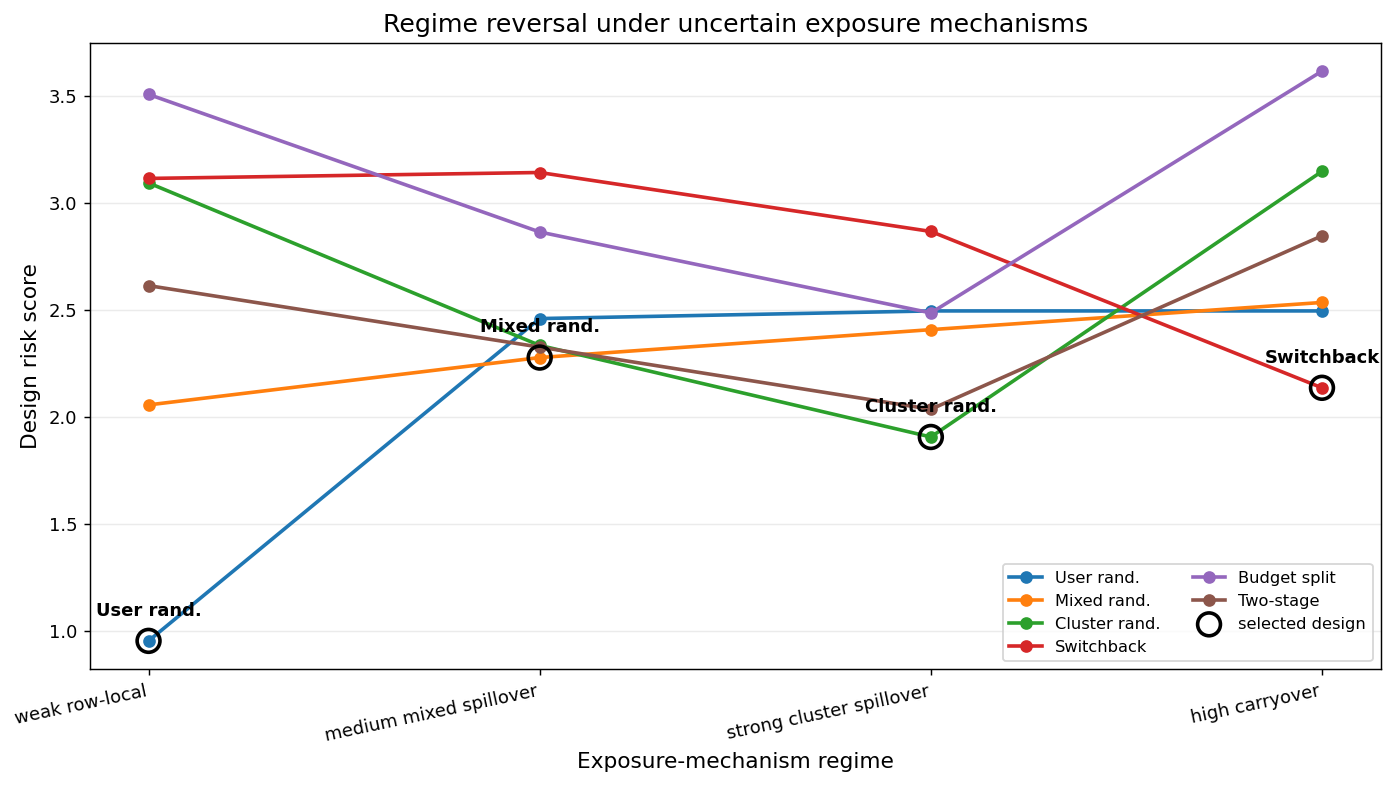

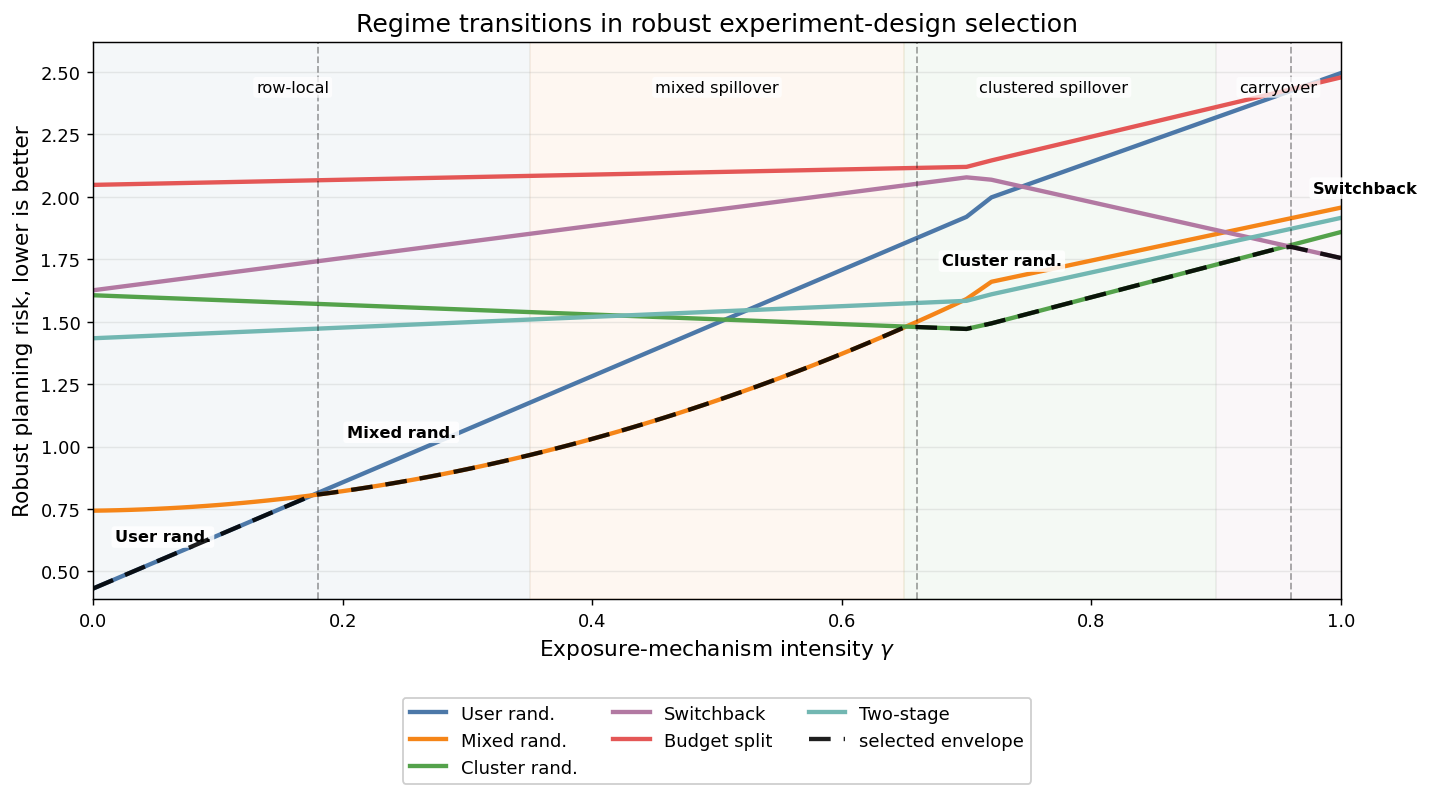

In [7]:
progress.log("Sweeping interference strength to show when naive user randomization degrades.")
sensitivity = run_interference_sensitivity(n_reps=80)
write_table(sensitivity, paths.table_dir / "01_interference_sensitivity.csv")
fig_path = paths.figure_dir / "01_interference_sensitivity.png"
plot_sensitivity_grid(sensitivity, fig_path)
display(Image(filename=fig_path))

progress.log("Constructing a mechanism-regime reversal diagnostic for the design-regime theorem.")
regime_reversal = run_regime_reversal_diagnostic()
write_table(regime_reversal, paths.table_dir / "01_regime_reversal_design_map.csv")
fig_path = paths.figure_dir / "01_regime_reversal_design_map.png"
plot_regime_reversal_map(regime_reversal, fig_path)
display(Image(filename=fig_path))

progress.log("Sweeping the continuous regime-transition curve for the centerpiece figure.")
regime_transition = run_continuous_regime_transition(n_points=101)
write_table(regime_transition, paths.table_dir / "01_regime_transition_design_risks.csv")
fig_path = paths.figure_dir / "01_regime_transition_design_risks.png"
plot_regime_transition_curves(regime_transition, fig_path)
display(Image(filename=fig_path))
regime_transition[regime_transition["is_selected"]].groupby("design").agg(
    min_gamma=("gamma", "min"),
    max_gamma=("gamma", "max"),
    n_grid_points=("gamma", "size"),
)
